In [189]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [190]:
# Load the dataset
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")

In [191]:
#quick look at the dataset
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [192]:
df.shape

(374, 13)

In [193]:
#displaying the datatypes of the columns
df['Age'].nunique()

31

In [194]:
df.info()
df.describe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


<bound method NDFrame.describe of      Person ID  Gender  Age            Occupation  Sleep Duration  \
0            1    Male   27     Software Engineer             6.1   
1            2    Male   28                Doctor             6.2   
2            3    Male   28                Doctor             6.2   
3            4    Male   28  Sales Representative             5.9   
4            5    Male   28  Sales Representative             5.9   
..         ...     ...  ...                   ...             ...   
369        370  Female   59                 Nurse             8.1   
370        371  Female   59                 Nurse             8.0   
371        372  Female   59                 Nurse             8.1   
372        373  Female   59                 Nurse             8.1   
373        374  Female   59                 Nurse             8.1   

     Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                   6                       42             6

In [195]:
#drop exact duplicate rows
df = df.drop_duplicates()

In [196]:
#dropping sleep disorder column
df.drop(columns=['Sleep Disorder'], inplace=True)

In [197]:
#missing values summary
df.isnull().sum()

Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
dtype: int64

In [198]:
#checking final column after dropping
print(df.columns)

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps'],
      dtype='object')


In [199]:
#checking datatype of blood pressure column
df['Blood Pressure'].dtype

dtype('O')

In [200]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000


In [201]:
## Split the 'Blood Pressure' column (e.g., "120/80") into two new columns: BP_systolic and BP_diastolic
df[['BP_systolic', 'BP_diastolic']] = df['Blood Pressure'].str.split('/', expand=True)

In [202]:
## Convert column from string to numeric (invalid values become NaN)
df['BP_systolic'] = pd.to_numeric(df['BP_systolic'], errors='coerce')
df['BP_diastolic'] = pd.to_numeric(df['BP_diastolic'], errors='coerce')

In [203]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,BP_systolic,BP_diastolic
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,140,90


In [204]:
## Drop the original 'Blood Pressure' column since we have split it into systolic and diastolic
df = df.drop(columns=['Blood Pressure'])

In [205]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,BP_systolic,BP_diastolic
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,140,90


In [206]:
#displaying the datatypes of the columns
df.dtypes

Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Heart Rate                   int64
Daily Steps                  int64
BP_systolic                  int64
BP_diastolic                 int64
dtype: object

In [207]:
#saved the cleaned to csv
df.to_csv("cleaned_sleep_health_and_lifestyle_dataset.csv", index=False)

In [208]:
df_cleaned= pd.read_csv("cleaned_sleep_health_and_lifestyle_dataset.csv")

In [209]:
#1. Identify numeric columns ---
numeric_cols = df_cleaned.select_dtypes(include='number').columns
print("Numeric columns:", numeric_cols.tolist())

#2. IQR outlier detection function ---
def detect_outliers_iqr(series):
    s = series.dropna()                          # avoid errors from NaN
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return s[(s < lower) | (s > upper)]          # return only outliers

#3. Loop through each numeric column ---
for col in numeric_cols:
    outliers = detect_outliers_iqr(df_cleaned[col])
    print(f"{col} → Outliers count: {len(outliers)}")



Numeric columns: ['Person ID', 'Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps', 'BP_systolic', 'BP_diastolic']
Person ID → Outliers count: 0
Age → Outliers count: 0
Sleep Duration → Outliers count: 0
Quality of Sleep → Outliers count: 0
Physical Activity Level → Outliers count: 0
Stress Level → Outliers count: 0
Heart Rate → Outliers count: 15
Daily Steps → Outliers count: 0
BP_systolic → Outliers count: 0
BP_diastolic → Outliers count: 0


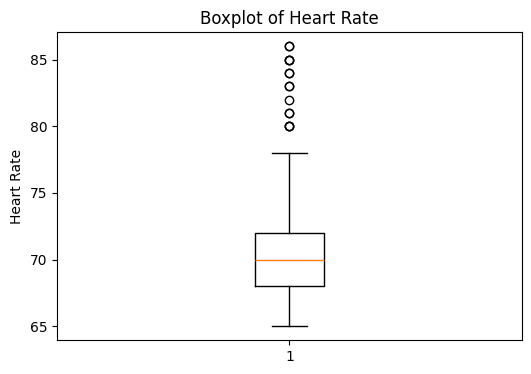

In [210]:
#boxplot for heart rate column as it shows outliers 
plt.figure(figsize=(6,4))
plt.boxplot(df_cleaned['Heart Rate'].dropna())
plt.title("Boxplot of Heart Rate")
plt.ylabel("Heart Rate")
plt.show()


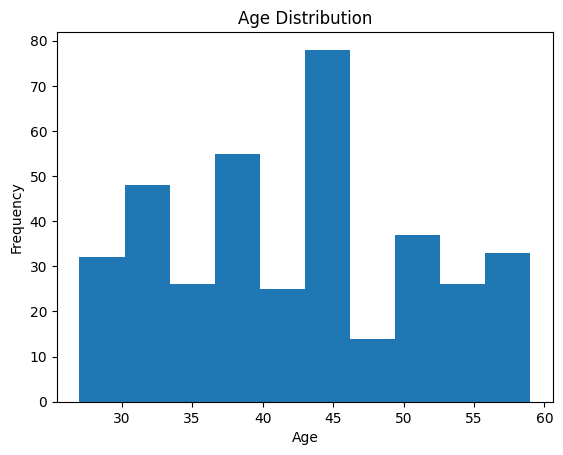

In [211]:
#1.Histogram
#Age is a continuous variable, so a histogram is best to show its distribution.
#This helps reveal whether the dataset is balanced or skewed toward certain age ranges.
#A bar chart is unsuitable here since it’s meant for categorical data, not continuous values.
plt.hist(df['Age'], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

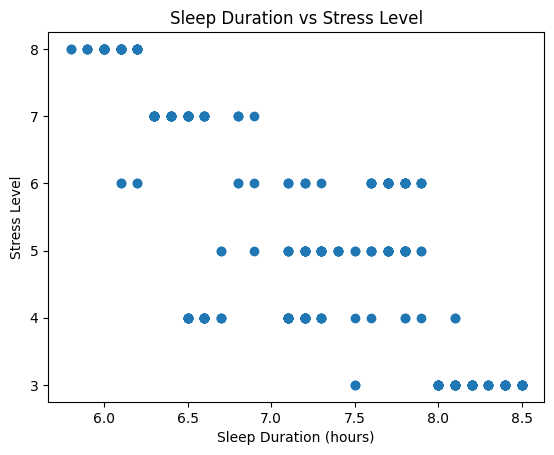

In [212]:
#2.# Key lifestyle insight: less sleep = more stress?
# Scatter plot shows correlation between two continuous variables
# Bar/pie charts can't show value-to-value relationships
# Trend: more sleep → lower stress
# Negative correlation: sleep duration vs stress level

plt.scatter(df['Sleep Duration'], df['Stress Level'])
plt.title("Sleep Duration vs Stress Level")
plt.xlabel("Sleep Duration (hours)")
plt.ylabel("Stress Level")
plt.show()

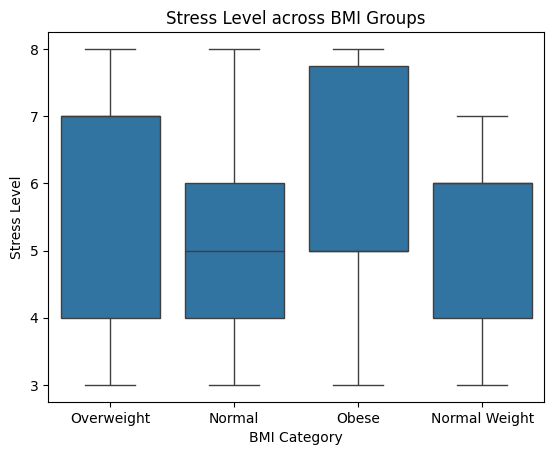

In [213]:
#This boxplot titled "Stress Level across BMI Groups" visualizes how stress levels vary among individuals with different BMI categories: Overweight, Normal, Obese, and Normal Weight.
sns.boxplot(x='BMI Category', y='Stress Level', data=df)
plt.title("Stress Level across BMI Groups")
plt.show()

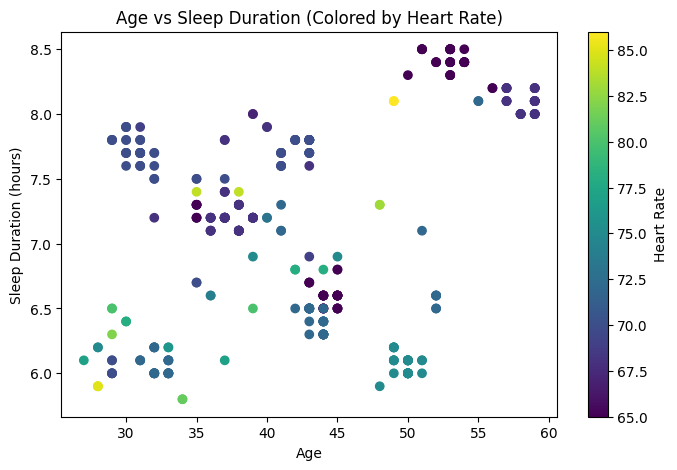

In [217]:
#This scatter plot shows the relationship between Age and Sleep Duration, with each point colored according to the person's Heart Rate.
# Set the size of the plot (width=8, height=5 inches)
plt.figure(figsize=(8,5))

# Create a scatter plot:
# x-axis  → Age
# y-axis  → Sleep Duration
# color   → Heart Rate values (shown using a color map)
scatter = plt.scatter(
    df['Age'],
    df['Sleep Duration'],
    c=df['Heart Rate'],       # third column shown as color
    cmap='viridis'
)
#Add a color bar on the side to show heart rate values
plt.colorbar(scatter, label='Heart Rate')

# Add title and axis labels
plt.title('Age vs Sleep Duration (Colored by Heart Rate)')
plt.xlabel('Age')
plt.ylabel('Sleep Duration (hours)')

# Display the plot
plt.show()

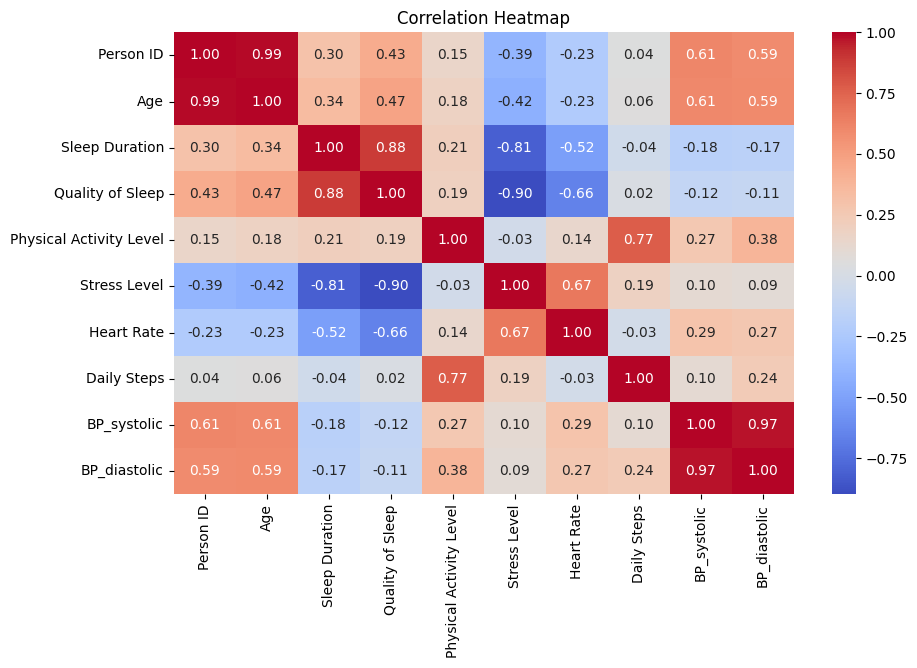

In [188]:
#This heatmap visualizes how strongly different health and activity variables are related to each other.
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()